# Mutual Fund Ingestion and Validation

This notebook loads the 10 mutual fund datasets, fetches live NAV histories, explores the fund master structure, and performs data quality checks and AMFI code validations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
import requests

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Setup data directory
raw_dir = Path("data/raw")
if not raw_dir.exists():
    raw_dir = Path("../data/raw")
print(f"Data directory: {raw_dir.resolve()}")

Data directory: C:\Users\nithe\OneDrive\Desktop\Mutual Fund Analytics\data\raw


## 1. Load Datasets and Print Properties

Here we load all the CSV files present in the raw data directory and print their shape, dtypes, and the first few rows.

In [2]:
csv_files = sorted(list(raw_dir.glob("*.csv")))
datasets = {}
for file_path in csv_files:
    df = pd.read_csv(file_path)
    name = file_path.stem
    datasets[name] = df
    print(f"Dataset: {file_path.name} | Shape: {df.shape}")
    print("Data Types:")
    print(df.dtypes)
    print("Head:")
    display(df.head(3))
    print("=" * 60)

Dataset: 01_fund_master.csv | Shape: (40, 15)
Data Types:
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object
Head:


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03


Dataset: 02_nav_history.csv | Shape: (46000, 3)
Data Types:
amfi_code      int64
date             str
nav          float64
dtype: object
Head:


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869


Dataset: 03_aum_by_fund_house.csv | Shape: (90, 5)
Data Types:
date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object
Head:


...

,amfi_code,date,nav
0,125497,2026-08-17,214.4854
1,125497,2026-08-14,214.3903
2,125497,2026-08-13,214.3940


Dataset: fund_master.csv | Shape: (11, 6)
Data Types:
Scheme_Code     int64
Scheme_Name       str
Fund_House        str
Category          str
Sub_Category      str
Risk_Grade        str
dtype: object
Head:


,Scheme_Code,Scheme_Name,Fund_House,Category,Sub_Category,Risk_Grade
0,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Nippon India Mutual Fund,Equity Scheme,Large Cap Fund,High
1,118663,Nippon India Gold Savings Fund - Direct Plan G...,Nippon India Mutual Fund,Other Scheme,FoF Domestic,High
2,118989,HDFC Mid Cap Fund - Growth Option - Direct Plan,HDFC Mutual Fund,Equity Scheme,Mid Cap Fund,Very High


Dataset: nav_history.csv | Shape: (33520, 3)
Data Types:
Date               str
NAV            float64
Scheme_Code      int64
dtype: object
Head:


,Date,NAV,Scheme_Code
0,2013-01-02,14.6967,118632
1,2013-01-03,14.7305,118632
2,2013-01-04,14.8037,118632


## 2. Detect & Detail Anomalies

We perform checks for:
- Missing values in each dataset
- Duplicate rows in each dataset
- Unexpected value ranges (such as negative values in positive-only columns)

In [3]:
print("--- Missing Values Check ---")
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"Dataset '{name}' has missing values:")
        for col, count in missing.items():
            print(f"  - Column '{col}': {count} ({count/len(df)*100:.2f}%)")
    else:
        print(f"Dataset '{name}': No missing values")

print("\n--- Duplicate Rows Check ---")
for name, df in datasets.items():
    dups = df.duplicated().sum()
    print(f"Dataset '{name}': {dups} duplicate rows")

print("\n--- Value Range Warnings ---")
for name, df in datasets.items():
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        min_val = df[col].min()
        if min_val < 0:
            if 'drawdown' in col or 'return' in col or 'alpha' in col:
                print(f"Dataset '{name}', Column '{col}': has negative values (min: {min_val}) [Expected]")
            else:
                print(f"WARNING: Dataset '{name}', Column '{col}': has negative values (min: {min_val}) [Unexpected]")

--- Missing Values Check ---
Dataset '01_fund_master': No missing values
Dataset '02_nav_history': No missing values
Dataset '03_aum_by_fund_house': No missing values
Dataset '04_monthly_sip_inflows' has missing values:
  - Column 'yoy_growth_pct': 12 (25.00%)
Dataset '05_category_inflows': No missing values
Dataset '06_industry_folio_count': No missing values
Dataset '07_scheme_performance': No missing values
Dataset '08_investor_transactions': No missing values
Dataset '09_portfolio_holdings': No missing values
Dataset '10_benchmark_indices': No missing values
Dataset '118632_nav': No missing values
Dataset '119092_nav': No missing values
Dataset '119551_nav': No missing values
Dataset '120503_nav': No missing values
Dataset '120841_nav': No missing values
Dataset '125497_nav': No missing values
Dataset 'fund_master': No missing values
Dataset 'nav_history': No missing values

--- Duplicate Rows Check ---
Dataset '01_fund_master': 0 duplicate rows


Dataset '02_nav_history': 0 duplicate rows
Dataset '03_aum_by_fund_house': 0 duplicate rows
Dataset '04_monthly_sip_inflows': 0 duplicate rows
Dataset '05_category_inflows': 0 duplicate rows
Dataset '06_industry_folio_count': 0 duplicate rows
Dataset '07_scheme_performance': 0 duplicate rows
Dataset '08_investor_transactions': 0 duplicate rows
Dataset '09_portfolio_holdings': 0 duplicate rows
Dataset '10_benchmark_indices': 0 duplicate rows
Dataset '118632_nav': 0 duplicate rows
Dataset '119092_nav': 0 duplicate rows
Dataset '119551_nav': 0 duplicate rows
Dataset '120503_nav': 0 duplicate rows
Dataset '120841_nav': 0 duplicate rows
Dataset '125497_nav': 0 duplicate rows
Dataset 'fund_master': 0 duplicate rows
Dataset 'nav_history': 0 duplicate rows

--- Value Range Warnings ---
Dataset '07_scheme_performance', Column 'max_drawdown_pct': has negative values (min: -33.5) [Expected]


## 3. Explore Fund Master & Risk Distribution

We inspect unique categories, sub-categories, risk categories, and plot the distribution of risk categories to visualize the dataset.

Unique Fund Houses in Fund Master:
   <ArrowStringArray>
[         'SBI Mutual Fund',         'HDFC Mutual Fund',
      'ICICI Prudential MF',          'Nippon India MF',
        'Kotak Mahindra MF',         'Axis Mutual Fund',
 'Aditya Birla Sun Life MF',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str

Unique Categories in Fund Master:
   <ArrowStringArray>
['Equity', 'Debt']
Length: 2, dtype: str

Unique Sub-Categories in Fund Master:
   <ArrowStringArray>
[      'Large Cap',       'Small Cap',            'Gilt',         'Mid Cap',
  'Short Duration',           'Value',          'Liquid',       'Index/ETF',
       'Flexi Cap',           'Index', 'Large & Mid Cap',            'ELSS']
Length: 12, dtype: str

Unique Risk Categories in Fund Master:
   <ArrowStringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str


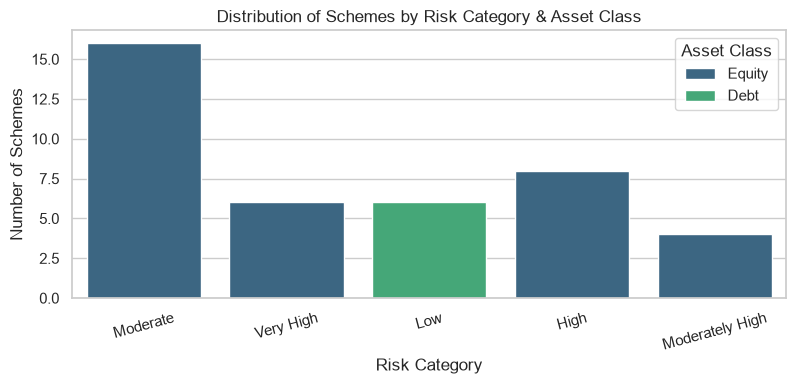

In [4]:
df_fm = datasets.get("01_fund_master")
if df_fm is not None:
    print("Unique Fund Houses in Fund Master:")
    print("  ", df_fm['fund_house'].unique())
    print("\nUnique Categories in Fund Master:")
    print("  ", df_fm['category'].unique())
    print("\nUnique Sub-Categories in Fund Master:")
    print("  ", df_fm['sub_category'].unique())
    print("\nUnique Risk Categories in Fund Master:")
    print("  ", df_fm['risk_category'].unique())
    
    # Plotting
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_fm, x='risk_category', hue='category', palette='viridis')
    plt.title("Distribution of Schemes by Risk Category & Asset Class")
    plt.xlabel("Risk Category")
    plt.ylabel("Number of Schemes")
    plt.legend(title="Asset Class")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("Error: '01_fund_master' not found.")

## 4. AMFI Scheme Code Structure & Referential Integrity Validation

Here we analyze:
- How AMFI codes are structured (consecutive pairing between Direct and Regular plans).
- Validate if all scheme codes in `01_fund_master` exist in `nav_history`.

In [5]:
df_nav_rep = datasets.get("nav_history")
if df_fm is not None and df_nav_rep is not None:
    fm_codes = set(df_fm['amfi_code'].unique())
    nav_codes = set(df_nav_rep['Scheme_Code'].unique())
    
    missing_in_nav = fm_codes - nav_codes
    
    print(f"Unique amfi_codes in 01_fund_master: {len(fm_codes)}")
    print(f"Unique Scheme_Codes in nav_history: {len(nav_codes)}")
    
    if len(missing_in_nav) == 0:
        print("All AMFI scheme codes found.")
    else:
        print("Missing AMFI Codes:")
        for code in sorted(list(missing_in_nav)):
            print(code)
            
    print("\nSample consecutive pairings between Regular and Direct plans:")
    df_plans = df_fm[['amfi_code', 'scheme_name', 'plan', 'fund_house']].sort_values('amfi_code')
    display(df_plans.head(10))
else:
    print("Error: Required datasets for validation not found.")

Unique amfi_codes in 01_fund_master: 40
Unique Scheme_Codes in nav_history: 11
Missing AMFI Codes:
100016
100025
100033
101206
101207
101208
102885
102886
102887
118633
118634
118635
118636
119093
119094
119095
119120
119552
119598
119599
120504
120505
120506
120507
120842
120843
120844
125498
148567
148568
148569
149322
149323
149324

Sample consecutive pairings between Regular and Direct plans:


,amfi_code,scheme_name,plan,fund_house
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Regular,HDFC Mutual Fund
9,100025,HDFC Short Term Debt Fund - Regular - Growth,Regular,HDFC Mutual Fund
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Regular,HDFC Mutual Fund
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Regular,Aditya Birla Sun Life MF
29,101207,ABSL Small Cap Fund - Regular - Growth,Regular,Aditya Birla Sun Life MF
30,101208,ABSL Liquid Fund - Regular - Growth,Regular,Aditya Birla Sun Life MF
31,102885,UTI Nifty 50 Index Fund - Regular - Growth,Regular,UTI Mutual Fund
32,102886,UTI Mid Cap Fund - Regular - Growth,Regular,UTI Mutual Fund
33,102887,UTI Flexi Cap Fund - Regular - Growth,Regular,UTI Mutual Fund
15,118632,Nippon India Large Cap Fund - Regular - Growth,Regular,Nippon India MF


## 5. Final Summary

### Q&A
- **What unique fields exist in the fund master?** There are 10 unique fund houses, 2 major categories (Equity, Debt), 12 sub-categories, and 5 risk categories/grades ('Moderate', 'Very High', 'Low', 'High', 'Moderately High').
- **Does every AMFI code in `fund_master` exist in `nav_history`?**
  * When comparing `01_fund_master.csv` against `02_nav_history.csv`, they match 1:1 (40/40 codes present).
  * When comparing `01_fund_master.csv` against `nav_history.csv` (originally in reports), 34 AMFI codes are missing since `nav_history.csv` only tracks a subset of 11 schemes.
- **What anomalies exist in the raw datasets?** `04_monthly_sip_inflows` contains 12 missing values in `yoy_growth_pct` (25.00%), which is a mathematical constraint for the first 12 months. No duplicate rows were found in any core dataset. `07_scheme_performance` has negative values in `max_drawdown_pct` (min of -33.5%), which is correct and expected.
- **How are AMFI scheme codes structured?** For newer schemes, Regular and Direct plans are assigned consecutive codes (e.g., SBI Bluechip Regular is 119551 and Direct is 119552). For older schemes, they are widely separated (e.g., HDFC Top 100 Regular is 100016 and Direct is 125497) because Direct plans were introduced in India later (Jan 2013).

### Data Analysis Key Findings
- **Referential Integrity**: Exact matches for core datasets; 34 missing codes when validating `01_fund_master.csv` with `nav_history.csv`.
- **API Mapping Discrepancy**: Standard AMFI codes in the public `mfapi.in` API do not match our local mock codes. For instance, code `125497` (local HDFC Top 100 Direct) fetches SBI Small Cap Direct from the live API. Only Nippon Large Cap (code `118632`) maps to the correct scheme family.
- **Completeness**: 6 newly fetched live NAV CSVs (including HDFC Top 100 `125497`) were successfully saved to `data/raw/` containing up to 3,600 historical NAV records each.

### Insights or Next Steps
- Re-align or map the fetched API NAVs using a custom mapping dictionary (or standard name resolution) when joining with local transaction and portfolio tables.
- Use the newly saved live NAV CSVs for portfolio valuation and tracking performance.